In [249]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import re
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from wordcloud import WordCloud

## Exploratory Data Analysis

In [250]:
df = pd.read_csv("../input/tweet.csv")
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [251]:
df.isna().sum()

id       0
label    0
tweet    0
dtype: int64

In [252]:
df.duplicated().sum()

np.int64(0)

In [253]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [254]:
df['label'].unique()

array([0, 1])

In [255]:
df.shape

(31962, 3)

In [256]:
df[df["label"]==0].shape[0]

29720

In [257]:
df[df["label"]==1].shape[0]

2242

## Data Preprocessing:

In [258]:
def remove_patterns(data, pattern):
    result = re.findall(pattern,data)
    for word in result:
        #re.sub(pattern, replacement, string, count=0, flags=0)
        data = re.sub(word, "", data)
    return data

In [259]:
df['cleaned'] = df['tweet'].map(lambda x: remove_patterns(x, r"@[\w]+"))
df.head()

,id,label,tweet,cleaned
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so sel...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks for #lyft credit i can't use cause th...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation,factsguide: society now #motivation


In [260]:
df['cleaned'] = df['cleaned'].map(lambda x: remove_patterns(x, r"#[\w]+"))
df.head()

,id,label,tweet,cleaned
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so sel...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks for credit i can't use cause they do...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,i love u take with u all the time in urð±...
4,5,0,factsguide: society now #motivation,factsguide: society now


In [261]:
df['cleaned'] = df['cleaned'].str.replace(r"[^a-zA-Z\s]", "",regex=True)
df.head()

,id,label,tweet,cleaned
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so sel...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks for credit i cant use cause they don...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,i love u take with u all the time in ur
4,5,0,factsguide: society now #motivation,factsguide society now


In [262]:
df["cleaned"] = df["cleaned"].apply(lambda x: " ".join([word.lower() for word in x.split() if len(word)>3]))
df.head()

,id,label,tweet,cleaned
0,1,0,@user when a father is dysfunctional and is s...,when father dysfunctional selfish drags kids i...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks credit cant cause they dont offer wheel...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,love take with time
4,5,0,factsguide: society now #motivation,factsguide society


In [263]:
tokenized = df["cleaned"].apply(word_tokenize)
tokenized.head()

0    [when, father, dysfunctional, selfish, drags, ...
1    [thanks, credit, cant, cause, they, dont, offe...
2                              [bihday, your, majesty]
3                             [love, take, with, time]
4                                [factsguide, society]
Name: cleaned, dtype: object

In [264]:
stop_words = set(stopwords.words("english"))
tokenized = tokenized.apply(lambda x: [word for word in x if word.lower() not in stop_words])
tokenized.head()

0    [father, dysfunctional, selfish, drags, kids, ...
1    [thanks, credit, cant, cause, dont, offer, whe...
2                                    [bihday, majesty]
3                                   [love, take, time]
4                                [factsguide, society]
Name: cleaned, dtype: object

In [265]:
steamer = PorterStemmer()
tokenized = tokenized.apply(lambda x: [steamer.stem(word) for word in x])
tokenized.head()

0     [father, dysfunct, selfish, drag, kid, dysfunct]
1    [thank, credit, cant, caus, dont, offer, wheel...
2                                    [bihday, majesti]
3                                   [love, take, time]
4                                 [factsguid, societi]
Name: cleaned, dtype: object

In [266]:
# compine all words into one sentance in cleaned column
for i in range(len(tokenized)):
    tokenized[i] = " ".join(tokenized[i])
df["cleaned"] = tokenized
df.head()

,id,label,tweet,cleaned
0,1,0,@user when a father is dysfunctional and is s...,father dysfunct selfish drag kid dysfunct
1,2,0,@user @user thanks for #lyft credit i can't us...,thank credit cant caus dont offer wheelchair van
2,3,0,bihday your majesty,bihday majesti
3,4,0,#model i love u take with u all the time in ...,love take time
4,5,0,factsguide: society now #motivation,factsguid societi


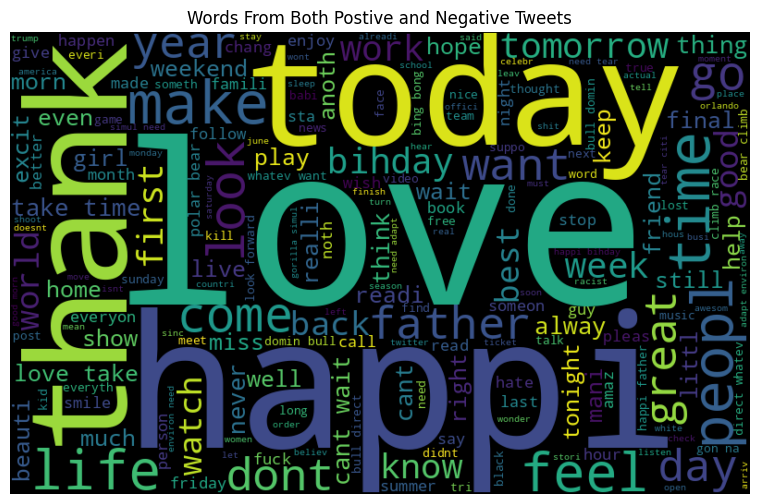

In [267]:
both_types = " ".join([sentence for sentence in df["cleaned"]])
word_cloud = WordCloud(width=800, height=500).generate(both_types)
plt.figure(figsize=(12,6))
plt.title("Words From Both Postive and Negative Tweets")
plt.imshow(word_cloud, interpolation= "bilinear")
plt.axis("off")
plt.show()

In [268]:
pos_word = " ".join([sentence for sentence in df["cleaned"][df["label"]==0]])
neg_word = " ".join([sentence for sentence in df["cleaned"][df["label"]==1]])

pos_cloud = WordCloud(width=800, height=500, colormap = "Greens").generate(pos_word)
neg_cloud = WordCloud(width=800, height=500, colormap = "Reds").generate(neg_word)

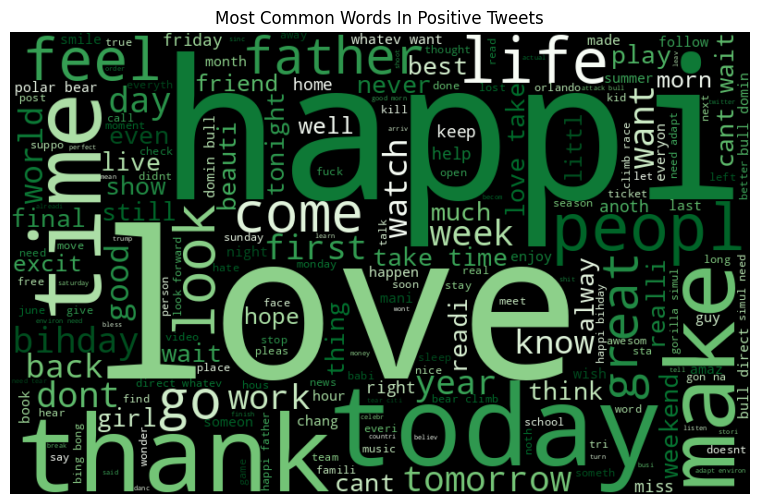

In [269]:
plt.figure(figsize=(12,6))
plt.title("Most Common Words In Positive Tweets")
plt.imshow(pos_cloud, interpolation= "bilinear")
plt.axis("off")
plt.show()

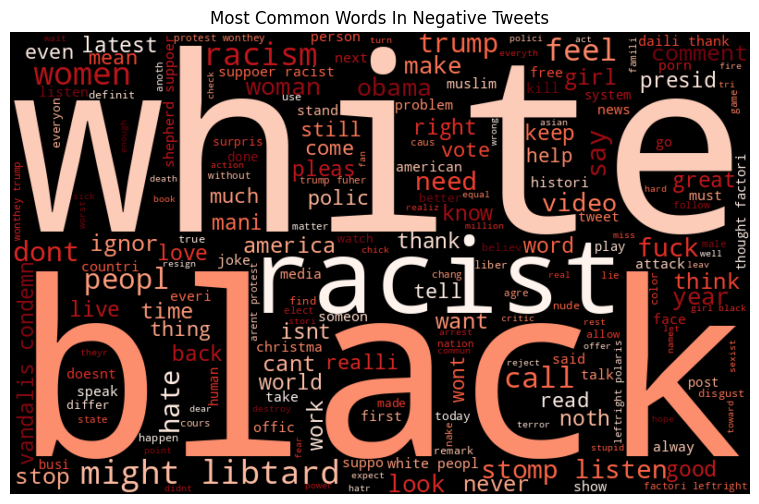

In [270]:
plt.figure(figsize=(12,6))
plt.title("Most Common Words In Negative Tweets")
plt.imshow(neg_cloud, interpolation= "bilinear")
plt.axis("off")
plt.show()